In [3]:

from data.EMG_dataset import EMGDataset
import torchvision
from torchvision import transforms

train_dataset = EMGDataset(
    transform = transforms.Compose([
        transforms.ToTensor()
    ]),
    root="compiled_data", 
    filename = "train_data.npz",
    participant_path = "..\\record\\emg_sessions\\train",
    force_compile = False,
)

val_dataset = EMGDataset(
    transform = transforms.Compose([
        transforms.ToTensor()
    ]),
    root="compiled_data", 
    filename = "val_data.npz",
    participant_path = "..\\record\\emg_sessions\\val",
    force_compile = False,
)

test_dataset = EMGDataset(
    transform = transforms.Compose([
        transforms.ToTensor()
    ]),
    root="compiled_data", 
    filename = "test_data.npz",
    participant_path = "..\\record\\emg_sessions\\test",
    force_compile = False,
)


In [4]:
from networks import EMGModel
import torch
# Hyperparameters
hparams = {'D': 16, # architecture
 'F1': 128, # architecture
 'F2': 128, # architecture
 'channels': 8,
 'dropout': 0.138, # training
 'early_stopping': {'burn_in': 4,
                    'cooldown': 4,
                    'min_delta': 0.00047912070773434816,
                    'mode': 'min',
                    'monitor': 'val_loss',
                    'patience': 15,
                    'restore_best': True},
 'extra_blocks': 1, # architecture
 'extra_dilation': 1, # architecture
 'extra_dropout': 0.138, # training
 'extra_kernel': 7, # architecture
 'kernel_length': 24, # architecture
 'num_classes': 9, # In case you want to remove mild classes it would become 5 classes only
 'optimization': {'batch_size': 24, # training
                  'criterion': 'nn.CrossEntropyLoss',
                  'epochs': 100, # training
                  'grad_clip': 2.0, # training
                  'lr': 0.00011396995431147184, # training
                  'optimizer': 'optim.AdamW'},
 'pool1_time': 3, # architecture
 'pool2_time': 8, # architecture
 'scheduler': {'factor': 0.649590522222718,
               'min_lr': 3.0570412165705003e-07,
               'mode': 'min',
               'monitor': 'val_loss',
               'name': 'torch.optim.lr_scheduler.ReduceLROnPlateau',
               'patience': 6,
               'step_mode': 'plateau',
               'verbose': True}}


# Check if CUDA is available and assign device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create an instance of the model
model = EMGModel(hparams).to(device)

Using device: cuda:0


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

def make_weighted_sampler(dataset, num_classes=9, smoothing=0.0):
    """
    Builds a WeightedRandomSampler so each class is drawn ~uniformly.
    `smoothing` in [0, 1): 0 = strict inverse-frequency; closer to 1 flattens weights.
    """
    # get labels as a 1D numpy array
    if hasattr(dataset, "y"):
        y = np.asarray(dataset.y)
    elif hasattr(dataset, "labels"):
        y = np.asarray(dataset.labels)
    else:
        raise AttributeError("Dataset must expose labels via `y` or `labels`.")

    counts = np.bincount(y, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0  # avoid div-by-zero if a class is missing

    inv = 1.0 / counts
    # optional smoothing to avoid extreme weights when a class is super-rare
    w_per_class = (1 - smoothing) * inv / inv.sum() * num_classes + smoothing * 1.0

    weights = w_per_class[y]  # per-sample weight
    weights = torch.as_tensor(weights, dtype=torch.double)

    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),    # one "epoch" roughly same number of samples
        replacement=True
    )
    return sampler

# --- usage ---
batch_size = hparams['optimization']['batch_size']
train_sampler = make_weighted_sampler(train_dataset, num_classes=9)

train_loader  = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, shuffle=False, drop_last=True)

# keep validation/test natural (no balancing there):
val_loader    = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

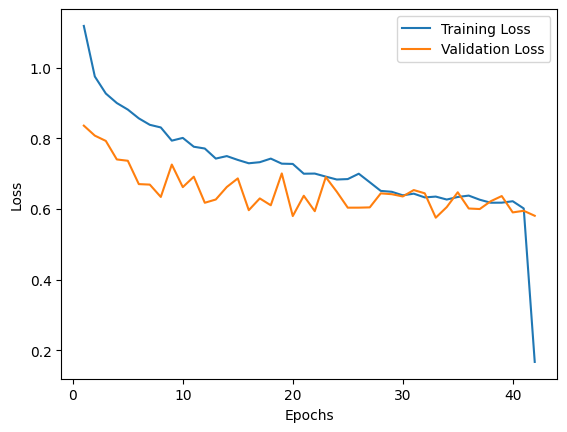

Renamed training session directory to models/EMGModel/2026-03-28_16-11-49_with_loss_0.5755


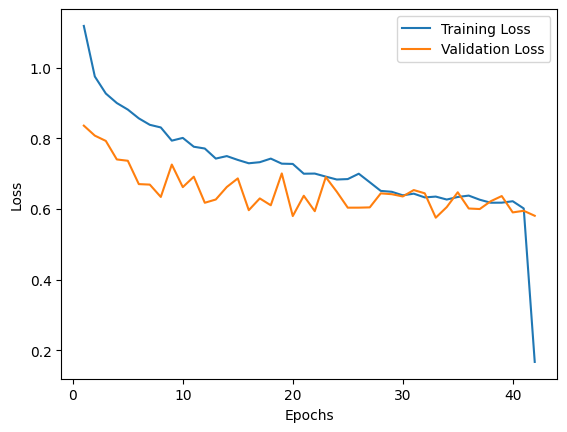

In [7]:
from training import train_model
train_model(model, train_loader, val_loader, device, hparams, plot_losses = True)